<a href="https://colab.research.google.com/github/Maurofome/Lab01_EDA_Aliaga_Mauricio/blob/main/Lab01_EDA_Aliaga_Mauricio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mauricio Aliaga
**Aplicación de CRISP-DM**

1.  Business Understanding: En este proyecto de universidad se intenta analizar una base de datos "Student Performance % Study Habits Dataset" en donde se quiere analizar como diferentes variables afectan el rendimiento academico de un alumno basado en habitos y factores demograficos. Se esta utilizando codigo entregado por el docente, utilizaremos el modelo CRISP-DM para realizar este analisis de datos.

2.  Data Understanding: Se descargan los registros de estudiantes de "Student Performance % Study Habits Dataset". Se descubre que en la columna de "parental_education" contiene 102 datos nulos de 1000 y el dataset no contiene filas duplicadas.

3.  Data Preparation: Se convierten columnas como "gender", "internet_access" y varios mas en un formato numero que sea adecuado para un modelo. Se atiende la columna de "parental_education" transnformando los nulos a "Unknown".

4.  Modeling: Se utiliza un modelo que pueda predecir el promedio final que tendra al final de semestre.

5.  Evaluation: Se evalua la eficacia del modelo probando con un 80% de datos y comparar la prediccion con el resto.

6.  Deployment: Formular un conjunto de recomendaciones concretas y accionables basadas en los insights derivados del modelo. Diseñar y preparar una presentación clara y efectiva para comunicar los resultados del análisis.



Nombre del dataset: Student Performance & Study Habits Dataset

 Autor o publicador: Harshada Patil

Enlace: https://www.kaggle.com/datasets/harshadapatil31/student-performance-and-study-habits-dataset

Archivo seleccionado: [student-performance-dataset.csv]

Unidad de análisis: Las filas son las siguientes:
  •	student_id: Identificador único para cada estudiante
  •	gender: Genero de cada estudiante entre Female y Male
  •	study_time_hours: Horas de studio al dia
  •	attendance_percent: Porcentaje de asistencia de clases
  •	sleep_hours: Horas de sueño
  •	parental_education: El grado de educación mas alto de sus padres
  •	internet_access: Si el estudiante posee conexión a internet
  •	extracurricular_activities: Si el estudiante tiene actividades académicas aparte de el estudio principal
  •	part_time_job: Si el estudiante tiene un trabajo part time
  •	previous_grade: Promedio previo del alumno
  •	final_exam_score: Nota final del alumno
  •	final_grade: Promedio final del alumno

Justificación: Me parece interesante esta base de datos y siento que contiene datos que podrían funcionar en esta actividad.

Pregunta inicial:

Licencia o condiciones de uso: Dominio publico


Se insertan las librerias correspondientes

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


Se sube el dataset seleccionado

In [ ]:
from google.colab import files
archivos_subidos = files.upload()
nombre_csv = next(iter(archivos_subidos))
print("Archivo seleccionado:", nombre_csv)

Saving student_performance_dataset.csv to student_performance_dataset (1).csv
Archivo seleccionado: student_performance_dataset (1).csv


Se carga el dataset para comprobar que se subio correctamente

In [ ]:
df = pd.read_csv(nombre_csv)
print("Dataset cargado correctamente")
df.head()


Dataset cargado correctamente


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.00,98.00,6.50,Bachelors,Yes,Yes,No,76.90,100.00,A
1,2,Female,6.30,100.00,5.70,High School,Yes,Yes,Yes,75.50,100.00,A
2,3,Male,4.90,85.30,7.90,Bachelors,Yes,No,Yes,88.50,97.30,A
3,4,Male,2.60,77.50,8.00,NaN,Yes,Yes,No,85.10,83.80,B
4,5,Male,2.20,89.60,4.60,Bachelors,Yes,No,Yes,61.80,68.30,D


Con este codigo la salido son la cantidad de filas y columnas


In [ ]:
filas, columnas = df.shape
print("El dataset contiene las siguientes filas:", filas , "y la siguiente cantidad de colummnas:" , columnas)

El dataset contiene las siguientes filas: 1000 y la siguiente cantidad de colummnas: 12


Observar el inicio de la tabla, el final y una muestra aleatoria

In [ ]:
display(df.head())
display(df.tail())
display(df.sample(n=min(5, len(df)), random_state=42))

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.00,98.00,6.50,Bachelors,Yes,Yes,No,76.90,100.00,A
1,2,Female,6.30,100.00,5.70,High School,Yes,Yes,Yes,75.50,100.00,A
2,3,Male,4.90,85.30,7.90,Bachelors,Yes,No,Yes,88.50,97.30,A
3,4,Male,2.60,77.50,8.00,NaN,Yes,Yes,No,85.10,83.80,B
4,5,Male,2.20,89.60,4.60,Bachelors,Yes,No,Yes,61.80,68.30,D


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
995,996,Male,2.80,75.40,8.20,Masters,Yes,Yes,No,60.50,70.70,C
996,997,Male,6.70,88.40,7.10,NaN,No,Yes,No,82.20,99.50,A
997,998,Female,2.60,84.50,8.00,High School,Yes,Yes,Yes,65.20,79.20,C
998,999,Female,4.60,85.30,8.10,High School,No,No,Yes,52.20,82.20,B
999,1000,Male,3.90,77.40,6.10,Masters,Yes,No,No,45.40,70.40,C


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
521,522,Male,4.60,73.70,5.40,PhD,No,Yes,Yes,74.80,71.80,C
737,738,Male,1.80,82.40,6.40,High School,Yes,No,Yes,70.90,66.60,D
740,741,Male,4.00,73.20,4.50,High School,Yes,No,No,49.40,62.90,D
660,661,Female,4.50,85.00,8.20,Bachelors,Yes,No,No,71.90,95.20,A
411,412,Female,4.50,77.00,4.70,High School,Yes,No,No,81.60,90.20,A


Se listan los nombres de las columnas

In [ ]:
print("Columnas disponibles:")

for numero, columna in enumerate(df.columns, start=1):
  print(numero, "−", columna)


Columnas disponibles:
1 − student_id
2 − gender
3 − study_time_hours
4 − attendance_percent
5 − sleep_hours
6 − parental_education
7 − internet_access
8 − extracurricular_activities
9 − part_time_job
10 − previous_grade
11 − final_exam_score
12 − final_grade


 Inspección general con info()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


Construir un resumen de columnas

In [ ]:
resumen_columnas = pd.DataFrame({
"tipo_pandas": df.dtypes.astype(str),
"datos_presentes": df.notna().sum(),
"datos_nulos": df.isna().sum(),
"valores_unicos": df.nunique(dropna=True)
})
resumen_columnas


,tipo_pandas,datos_presentes,datos_nulos,valores_unicos
student_id,int64,1000,0,1000
gender,object,1000,0,2
study_time_hours,float64,1000,0,70
attendance_percent,float64,1000,0,327
sleep_hours,float64,1000,0,65
parental_education,object,898,102,4
internet_access,object,1000,0,2
extracurricular_activities,object,1000,0,2
part_time_job,object,1000,0,2
previous_grade,float64,1000,0,434


Separa las columnas que pandas reconoce como numéricas y categóricas:


In [ ]:
columnas_numericas = df.select_dtypes(
include=np.number
).columns.tolist()
columnas_categoricas = df.select_dtypes(
include=["object", "category", "bool"]
).columns.tolist()
print("Columnas numericas:", columnas_numericas)
print("Columnas categoricas:", columnas_categoricas)


Columnas numericas: ['student_id', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']
Columnas categoricas: ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'final_grade']


Evaluar la calidad inicial

In [ ]:
resumen_nulos = pd.DataFrame({
"cantidad_nulos": df.isnull().sum(),
"porcentaje_nulos": (df.isnull().mean() *
100).round(2)
})
resumen_nulos = resumen_nulos.sort_values(
by="porcentaje_nulos",
ascending=False
)
resumen_nulos


,cantidad_nulos,porcentaje_nulos
parental_education,102,10.20
student_id,0,0.00
study_time_hours,0,0.00
gender,0,0.00
attendance_percent,0,0.00
sleep_hours,0,0.00
internet_access,0,0.00
extracurricular_activities,0,0.00
part_time_job,0,0.00
previous_grade,0,0.00


In [ ]:
columnas_con_nulos = resumen_nulos[
resumen_nulos["cantidad_nulos"] > 0
]
columnas_con_nulos


,cantidad_nulos,porcentaje_nulos
parental_education,102,10.20


Filas duplicadas


In [ ]:
cantidad_duplicados = df.duplicated().sum()
porcentaje_duplicados = cantidad_duplicados / len(df) * 100
print("Filas duplicadas:", cantidad_duplicados)
print("Porcentaje duplicado:", round(porcentaje_duplicados, 2), " %")

Filas duplicadas: 0
Porcentaje duplicado: 0.0  %


 Cantidad de valores diferentes

In [ ]:
valores_diferentes = df.nunique(dropna=False).sort_values()
valores_diferentes

,0
gender,2
extracurricular_activities,2
internet_access,2
part_time_job,2
final_grade,5
parental_education,5
sleep_hours,65
study_time_hours,70
attendance_percent,327
final_exam_score,342


 Resumen de columnas numéricas

In [ ]:
print(columnas_numericas)

['student_id', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']


 Genera el resumen


In [ ]:
if columnas_numericas:
  resumen_numerico = df[columnas_numericas].describe().T
  display(resumen_numerico)
else:
  print("El dataset no tiene columnas numericas detectadas")

,count,mean,std,min,25%,50%,75%,max
student_id,"1,000.00",500.50,288.82,1.00,250.75,500.50,750.25,"1,000.00"
study_time_hours,"1,000.00",3.57,1.48,0.50,2.60,3.60,4.50,8.10
attendance_percent,"1,000.00",85.09,9.27,54.80,78.80,85.20,91.90,100.00
sleep_hours,"1,000.00",6.80,1.20,3.20,5.90,6.80,7.60,10.00
previous_grade,"1,000.00",69.74,12.61,31.30,61.00,69.60,78.40,100.00
final_exam_score,"1,000.00",83.54,10.34,46.80,76.07,83.80,91.53,100.00


Comparar media y mediana


In [ ]:
if columnas_numericas:
  comparacion_centro = pd.DataFrame({
    "media": df[columnas_numericas].mean(),
    "mediana": df[columnas_numericas].median(),
    "desviacion_estandar": df[columnas_numericas].std(),
    "minimo": df[columnas_numericas].min(),
    "maximo": df[columnas_numericas].max()
})
display(comparacion_centro)

,media,mediana,desviacion_estandar,minimo,maximo
student_id,500.50,500.50,288.82,1.00,"1,000.00"
study_time_hours,3.57,3.60,1.48,0.50,8.10
attendance_percent,85.09,85.20,9.27,54.80,100.00
sleep_hours,6.80,6.80,1.20,3.20,10.00
previous_grade,69.74,69.60,12.61,31.30,100.00
final_exam_score,83.54,83.80,10.34,46.80,100.00


 Calcular percentiles ampliados


In [ ]:
if columnas_numericas:
  tabla_percentiles = df[columnas_numericas].quantile(
    [0.00, 0.05, 0.25, 0.50, 0.75, 0.95, 1.00]
  ).T
  tabla_percentiles.columns = [
    "min", "p05", "p25", "p50_mediana",
    "p75", "p95", "max"
]
display(tabla_percentiles)


,min,p05,p25,p50_mediana,p75,p95,max
student_id,1.00,50.95,250.75,500.50,750.25,950.05,"1,000.00"
study_time_hours,0.50,1.10,2.60,3.60,4.50,6.10,8.10
attendance_percent,54.80,69.09,78.80,85.20,91.90,100.00,100.00
sleep_hours,3.20,4.80,5.90,6.80,7.60,8.80,10.00
previous_grade,31.30,48.79,61.00,69.60,78.40,91.00,100.00
final_exam_score,46.80,66.40,76.07,83.80,91.53,100.00,100.00


 Resumen de columnas categóricas


In [ ]:
if columnas_categoricas:
  resumen_categorico = df[columnas_categoricas].describe().T
  display(resumen_categorico)
else:
  print("No se detectaron columnas categoricas")

,count,unique,top,freq
gender,1000,2,Female,510
parental_education,898,4,High School,356
internet_access,1000,2,Yes,854
extracurricular_activities,1000,2,Yes,572
part_time_job,1000,2,No,684
final_grade,1000,5,B,354


Frecuencias de una categoria

In [ ]:
print(columnas_categoricas)
# Cambia el indice si la primera columna no es adecuada.
columna_categorica = columnas_categoricas[0]
print("Columna elegida:", columna_categorica)

['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'final_grade']
Columna elegida: gender


Cantidad y porcentaje

In [ ]:
frecuencia = df[columna_categorica].value_counts(
  dropna=False
)
porcentaje = df[columna_categorica].value_counts(
  dropna=False,
  normalize=True
).mul(100).round(2)
tabla_frecuencias = pd.DataFrame({
  "cantidad": frecuencia,
  "porcentaje": porcentaje
})
tabla_frecuencias.head(15)


,cantidad,porcentaje
gender,,
Female,510,51.00
Male,490,49.00


Visualizar las distribuciones
Elegir una columna numérica

In [ ]:
print(columnas_numericas)
# Cambia el indice para elegir una variable significativa.
columna_numerica = columnas_numericas[0]
print("Columna elegida:", columna_numerica)

['student_id', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']
Columna elegida: student_id


Histograma con media y mediana


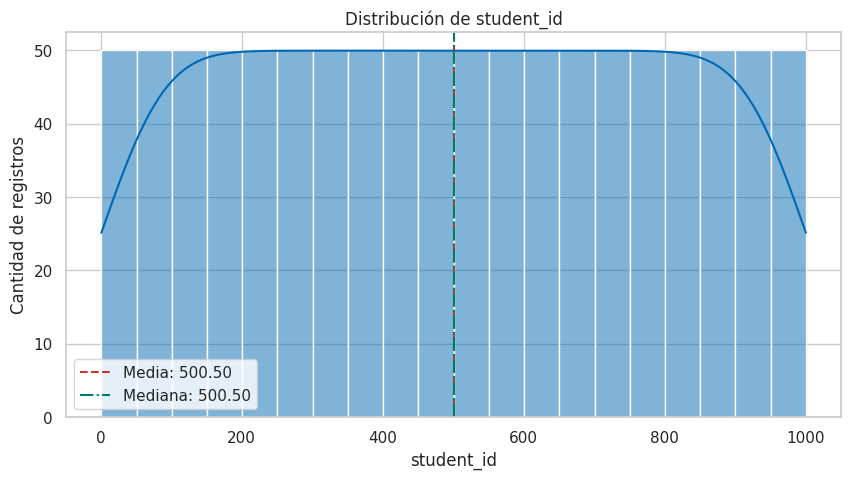

In [ ]:
media = df[columna_numerica].mean()
mediana = df[columna_numerica].median()

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x=columna_numerica,
    bins=20,
    kde=True,
    color="#0068B3"
)

plt.axvline(
    media,
    color="#C0392B",
    linestyle="--",
    label=f"Media: {media:.2f}"
)

plt.axvline(
    mediana,
    color="#007A6A",
    linestyle="-.",
    label=f"Mediana: {mediana:.2f}"
)

plt.title(f"Distribución de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.ylabel("Cantidad de registros")
plt.legend()
plt.show()

Diagrama de caja


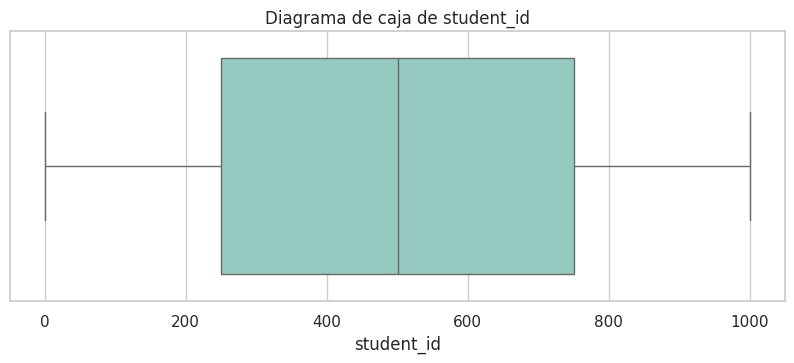

In [ ]:
plt.figure(figsize=(10, 3.5))

sns.boxplot(
  x=df[columna_numerica],
  color="#8ED1C6"
)

plt.title(f"Diagrama de caja de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.show()

Gráfico de barras para una columna categórica

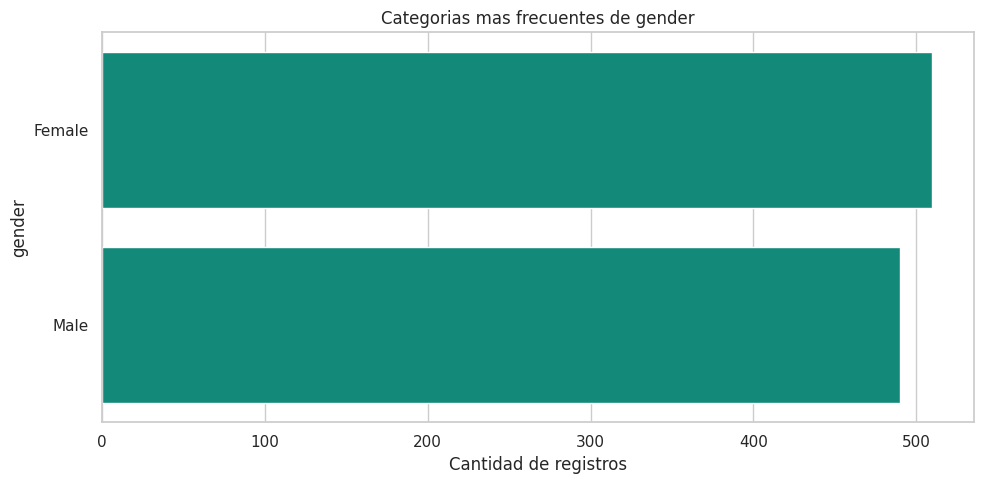

In [ ]:
top_categorias = df[columna_categorica].value_counts(
  dropna=False
).head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
  x=top_categorias.values,
  y=top_categorias.index.astype(str),
  color="#009C88"
)

plt.title(f"Categorias mas frecuentes de {columna_categorica}")
plt.xlabel("Cantidad de registros")
plt.ylabel(columna_categorica)
plt.tight_layout()
plt.show()


 Vista general de hasta seis variables numéricas

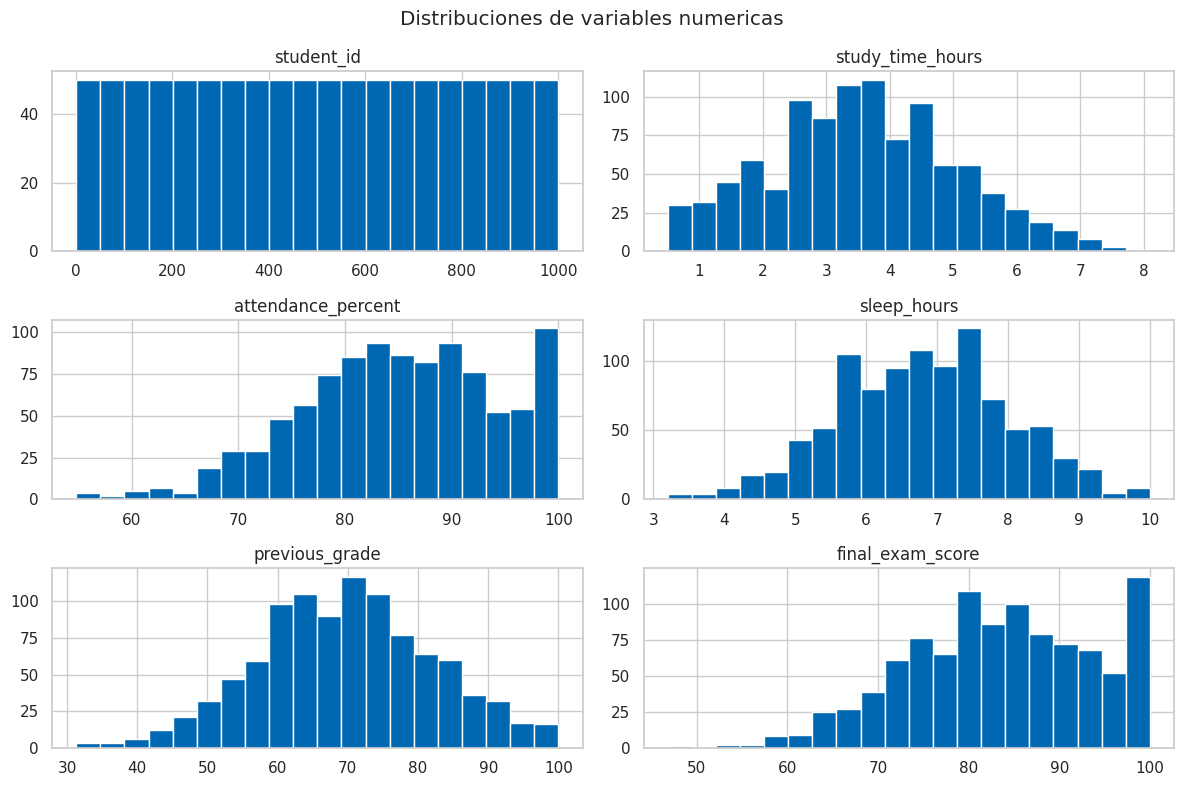

In [ ]:
seleccion_numericas = columnas_numericas[:6]

if seleccion_numericas:
  df[seleccion_numericas].hist(
    bins=20,
    figsize=(12, 8),
    color="#0068B3",
    edgecolor="white"
)
plt.suptitle("Distribuciones de variables numericas")
plt.tight_layout()
plt.show()


Exploración opcional de relación entre variables


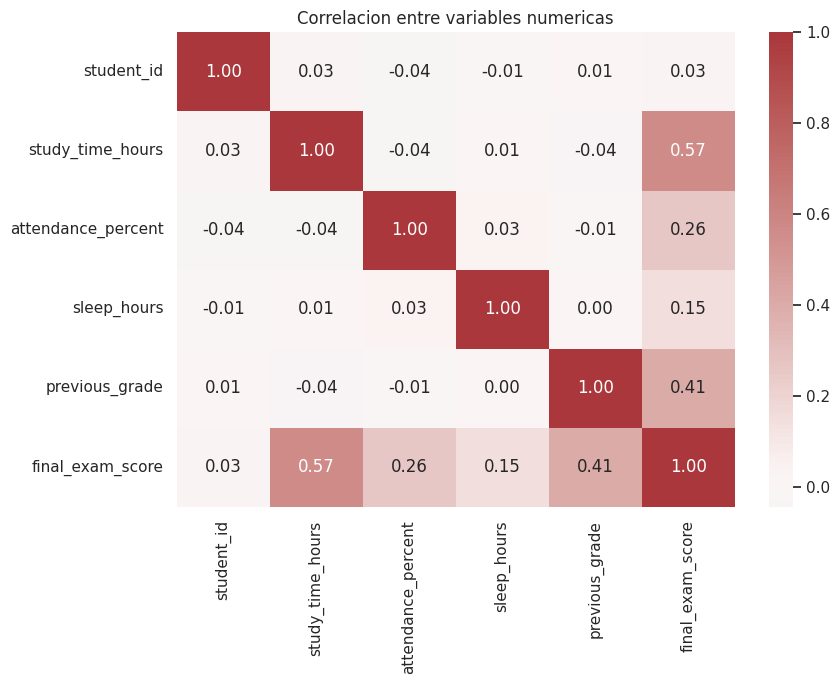

In [ ]:
seleccion_correlacion = columnas_numericas[:8]

if len(seleccion_correlacion) >= 2:
  matriz_correlacion = df[seleccion_correlacion].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
  matriz_correlacion,
  annot=True,
  fmt=".2f",
  cmap="vlag",
  center=0
)
plt.title("Correlacion entre variables numericas")
plt.tight_layout()
plt.show()


Evidencia encontrada:
Hay 1.000 filas y 12 columnas. Cada fila es un estudiante.
Hay 6 columnas con números y 6 con texto.
En parental_education existen datos nulos
El 85,4% tiene internet en casa y la nota final más común es la 'B'
0 Filas duplicadas

Conclusión sobre la utilidad del dataset:

Este dataset sirve para responder cómo se relacionan los hábitos de estudio, la asistencia y el entorno del alumno con sus notas finales. Su principal fortaleza es que está muy ordenado, no contitiene duplicados y las variables son claras y fáciles de entender.